# 兩頻道 Shorts 分析模板（template_two）

適用情境：類別有 2 個頻道（如遊戲、籃球幹片、籃球網紅、Kpop）。
核心檢定：Mann-Whitney U；OLS 含 0/1 channel dummy。

## 0. 參數

In [1]:
# === 參數區 ===========================================================
# 改類別只要改這三行；下方所有 cell 都引用這些變數
CSV_TIMESTAMP = "20260527-065002"      # 改這裡切換不同類別的資料
TARGET_CHANNELS = None                  # None = 全部；或填 list 過濾特定頻道
CATEGORY_NAME = "Kpop"               # 用於圖表標題、檔名
# ====================================================================


## 1. 匯入函式庫

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文字體（macOS 預設沒有 Microsoft 系列，使用 sans-serif 後備）
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 將 _templates/ 加入 sys.path 以便 import content_labeling
TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))

print("✓ 函式庫載入完成")


✓ 函式庫載入完成


## 2. 載入 CSV

In [3]:
# 載入資料（路徑從 analysis/<cat>/ 回退兩層到 final project/）
df = pd.read_csv(f'../../data/processed/channel_videos_{CSV_TIMESTAMP}.csv', encoding='utf-8')
df_channels = pd.read_csv(f'../../data/processed/channels_{CSV_TIMESTAMP}.csv', encoding='utf-8')

if TARGET_CHANNELS is not None:
    df = df[df['channel_title'].isin(TARGET_CHANNELS)].copy()

print(f"✓ 資料載入：{len(df)} 列影片 / {len(df_channels)} 列頻道")
print(f"頻道：{df['channel_title'].unique().tolist()}")


✓ 資料載入：308 列影片 / 2 列頻道
頻道：['kukuo 쿠쿠', 'K-潮流']


## 3. 檢視資料結構

In [4]:
print(df.dtypes)
print()
print('頻道列表：', df['channel_title'].unique())
print()
print(df.head())


video_id              str
title                 str
description           str
channel_id            str
channel_title         str
published_at          str
category_id         int64
tags                  str
default_language      str
duration_iso          str
duration_sec        int64
definition            str
caption              bool
view_count          int64
like_count          int64
comment_count       int64
favorite_count      int64
topic_categories      str
fetched_at            str
dtype: object

頻道列表： <StringArray>
['kukuo 쿠쿠', 'K-潮流']
Length: 2, dtype: str

      video_id            title  \
0  AsC9v4wBO9c    Yeji一句話馬上引起抗議   
1  7szh46ECyVo    彩領跟有娜的撒嬌都無可挑剔   
2  8NMdC_U4CtA      彩領露出的表情也超真實   
3  XIq4_UVPFMw  Wonhee完全就是無害小動物   
4  cfGGbpYlrdc  Lily每句都很真心就更好笑了   

                                         description  \
0                #Itzy #있지 #채령 #chaeryeong #예지 #yeji   
1    #Itzy #있지 #채령 #chaeryeong #유나 #yuna #류진 #ryujin   
2                 #Itzy #있지 #채령 #chaeryeong #lia

## 4. 資料清理與前處理

In [5]:
# 資料清理 + 派生欄位
df_clean = df.copy()
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 標題長度（混合 CJK + 英文之視覺字符數）
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)

# CJK / EN 分開計，跨類別比較時較公平
def count_cjk(s):
    return sum(1 for c in str(s) if '一' <= c <= '鿿')

def count_en_words(s):
    import re
    return len(re.findall(r'[A-Za-z]+', str(s)))

df_clean['title_length_cjk'] = df_clean['title'].fillna('').apply(count_cjk)
df_clean['title_length_en'] = df_clean['title'].fillna('').apply(count_en_words)

# tag_count: 用 flatten_video 的 '|' 串接，注意 NaN
df_clean['tag_count'] = df_clean['tags'].fillna('').apply(lambda s: 0 if not s else len(s.split('|')))

# Shorts 判定（沿用 Reg/02、Reg/03 的 180 秒閾值）
df_shorts = df_clean[df_clean['duration_sec'] <= 180].copy()

print(f"原始：{len(df_clean)}  Shorts (≤180s)：{len(df_shorts)}")
print(f"  每頻道 Shorts 篇數：")
print(df_shorts['channel_title'].value_counts())


原始：308  Shorts (≤180s)：298
  每頻道 Shorts 篇數：
channel_title
K-潮流        200
kukuo 쿠쿠     98
Name: count, dtype: int64


## 4.5 內容貼標（Layer 1-3）

In [6]:
# === §4.5 內容貼標（Layer 1-3） ============================
# 此 cell 由 content_labeling.py 注入
import content_labeling as cl

df_with_topics, topic_counts = cl.explode_topic_categories(df_shorts)
df_lab = cl.apply_keyword_labels(df_with_topics, text_cols=("title", "tags"))
buckets = cl.load_keyword_dict()
label_cols = [f"has_{b}" for b in buckets]

print("Layer 1 — topic 全體計數 (Top 15)：")
print(topic_counts.head(15))
print()

topic_dist = cl.topic_distribution_by_channel(df_with_topics)
print("Layer 1 — 頻道 × topic 比例：")
print(topic_dist)
print()

print("Layer 2 — 規則式關鍵字命中率（按頻道）：")
print(df_lab.groupby('channel_title')[label_cols].mean().round(3))
print()

try:
    tfidf = cl.tfidf_top_keywords_by_channel(df_lab, n=15)
    print("Layer 3 — TF-IDF Top 15 keywords / channel：")
    for ch, kws in tfidf.items():
        print(f"\n{ch}:")
        for kw, sc in kws:
            print(f"  {kw:20s}  {sc:.4f}")
except RuntimeError as e:
    print(f"Layer 3 跳過：{e}")


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


Layer 1 — topic 全體計數 (Top 15)：
Entertainment            218
Lifestyle_(sociology)     30
Humour                    12
Music                     11
Music_of_Asia             11
Television_program         7
Film                       3
Performing_arts            3
Pet                        3
Religion                   2
Video_game_culture         2
Sport                      2
Food                       1
Independent_music          1
Pop_music                  1
dtype: int64

Layer 1 — 頻道 × topic 比例：
          Entertainment     Music  Lifestyle_(sociology)    Pet  \
K-潮流           0.690000  0.035000               0.135000  0.015   
kukuo 쿠쿠       0.816327  0.040816               0.030612  0.000   

          Music_of_Asia  Performing_arts  Television_program  Humour  \
K-潮流           0.035000            0.015            0.015000    0.06   
kukuo 쿠쿠       0.040816            0.000            0.040816    0.00   

          Video_game_culture      Film  Sport  Pop_music  Health  Baseball  

Loading model cost 0.215 seconds.


Prefix dict has been built successfully.


Layer 3 — TF-IDF Top 15 keywords / channel：

K-潮流:
  xd                    0.3277
  karina                0.2230
  潮流                    0.2137
  真的                    0.2129
  自己                    0.2028
  ahyeon                0.1995
  rora                  0.1852
  看到                    0.1723
  怎麼                    0.1567
  chiquita              0.1567
  員瑛                    0.1567
  忍不住                   0.1425
  aespa                 0.1282
  立刻                    0.1282
  姐姐                    0.1282

kukuo 쿠쿠:
  haewon                0.4595
  bae                   0.3503
  yuna                  0.2626
  真的                    0.2569
  lily                  0.1868
  表情                    0.1635
  彩領                    0.1635
  nmixx                 0.1401
  真心                    0.1313
  jiwoo                 0.1168
  karina                0.1168
  kyujin                0.1168
  捉弄                    0.0985
  love                  0.0985
  完全                    0.0934


## 5. 描述性統計

In [7]:
# 描述性統計
metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec',
           'title_length', 'tag_count']
print("Shorts 主要指標統計：")
for m in metrics:
    if m in df_shorts.columns:
        d = df_shorts[m].dropna()
        if len(d) == 0:
            continue
        print(f"  {m:15s} mean={d.mean():>12,.1f}  median={d.median():>10,.1f}  std={d.std():>12,.1f}")

# 頻道級摘要
print("\n每頻道摘要：")
agg = df_shorts.groupby('channel_title').agg(
    n_shorts=('video_id', 'count'),
    mean_view=('view_count', 'mean'),
    median_view=('view_count', 'median'),
    mean_like=('like_count', 'mean'),
    mean_comment=('comment_count', 'mean'),
)
print(agg)


Shorts 主要指標統計：
  view_count      mean=   145,825.9  median=  50,548.5  std=   316,431.0
  like_count      mean=     3,267.8  median=   1,234.0  std=     5,887.5
  comment_count   mean=        22.3  median=      10.0  std=        34.3
  duration_sec    mean=        35.9  median=      31.0  std=        20.0
  title_length    mean=        40.5  median=      39.0  std=        21.9
  tag_count       mean=         1.6  median=       0.0  std=         2.3

每頻道摘要：
               n_shorts      mean_view  median_view    mean_like  mean_comment
channel_title                                                                 
K-潮流                200  102861.770000      54837.5  2568.530000     19.470000
kukuo 쿠쿠             98  233507.673469      17198.5  4694.836735     28.010204


## 6. 兩頻道差異檢定（Mann-Whitney U）

In [8]:
from scipy.stats import mannwhitneyu

chs = sorted(df_shorts['channel_title'].unique())
if len(chs) != 2:
    print(f"⚠ 頻道數 = {len(chs)}，非 two-channel；請改用其他模板或在 TARGET_CHANNELS 限縮")
else:
    ch1, ch2 = chs
    g1 = df_shorts[df_shorts['channel_title']==ch1]
    g2 = df_shorts[df_shorts['channel_title']==ch2]
    print(f"{ch1}: n={len(g1)}    {ch2}: n={len(g2)}")
    for m in ['view_count','like_count','comment_count','title_length','tag_count']:
        a = g1[m].dropna(); b = g2[m].dropna()
        if len(a) > 0 and len(b) > 0:
            u, p = mannwhitneyu(a, b, alternative='two-sided')
            sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
            print(f"  {m:15s} {ch1}={a.mean():>12,.1f}  {ch2}={b.mean():>12,.1f}  p={p:.4e} {sig}")


K-潮流: n=200    kukuo 쿠쿠: n=98
  view_count      K-潮流=   102,861.8  kukuo 쿠쿠=   233,507.7  p=4.4454e-02 *
  like_count      K-潮流=     2,568.5  kukuo 쿠쿠=     4,694.8  p=4.1153e-02 *
  comment_count   K-潮流=        19.5  kukuo 쿠쿠=        28.0  p=3.6157e-03 **
  title_length    K-潮流=        51.2  kukuo 쿠쿠=        18.7  p=6.8889e-37 ***
  tag_count       K-潮流=         0.4  kukuo 쿠쿠=         3.9  p=5.0679e-48 ***


## 7. 發佈時間趨勢

In [9]:
# 發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()
df_shorts['pub_hour_band'] = pd.cut(df_shorts['pub_hour'], bins=[-1,5,11,17,21,24],
                                     labels=['深夜','早','中','下','晚'])

# 按小時
print("按發佈時段平均觀看數：")
print(df_shorts.groupby('pub_hour_band', observed=False)['view_count'].mean().round(0))


按發佈時段平均觀看數：
pub_hour_band
深夜    110793.0
早      89010.0
中     266381.0
下          NaN
晚          NaN
Name: view_count, dtype: float64


## 7.1 相關性分析

In [10]:
# 相關性分析
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec',
                 'title_length', 'tag_count']
corr = df_shorts[analysis_cols].corr()
print("相關係數矩陣：")
print(corr.round(3))

print("\n與 view_count 的相關性顯著性檢定（Pearson）：")
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    d = df_shorts[[col, 'view_count']].dropna()
    if len(d) > 2:
        r, p = stats.pearsonr(d[col], d['view_count'])
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
        print(f"  {col:15s} r={r:+.4f}  p={p:.4e} {sig}")


相關係數矩陣：
               view_count  like_count  comment_count  duration_sec  \
view_count          1.000       0.926          0.802        -0.054   
like_count          0.926       1.000          0.824        -0.030   
comment_count       0.802       0.824          1.000         0.046   
duration_sec       -0.054      -0.030          0.046         1.000   
title_length       -0.152      -0.123         -0.122         0.001   
tag_count           0.101       0.084          0.060         0.374   

               title_length  tag_count  
view_count           -0.152      0.101  
like_count           -0.123      0.084  
comment_count        -0.122      0.060  
duration_sec          0.001      0.374  
title_length          1.000     -0.547  
tag_count            -0.547      1.000  

與 view_count 的相關性顯著性檢定（Pearson）：
  like_count      r=+0.9263  p=1.5961e-127 ***
  comment_count   r=+0.8024  p=2.5479e-68 ***
  duration_sec    r=-0.0543  p=3.5010e-01 ns
  title_length    r=-0.1518  p=8.6571e-03 

## 7.5 內容標籤與觀看數的關係

In [11]:
# === §7.5 內容標籤與觀看數的關係 ==========================
# 此 cell 由 content_labeling.py 注入：卡方 + logistic
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# 高觀看 = top quartile（每頻道內或整體）
view_q3 = df_lab['view_count'].quantile(0.75)
df_lab['top_quartile'] = (df_lab['view_count'] >= view_q3).astype(int)

print(f"top_quartile 門檻：view_count >= {view_q3:,.0f}")
print()

print("每個 label vs 高觀看 卡方檢定：")
for col in label_cols:
    if df_lab[col].sum() < 5 or df_lab[col].sum() > len(df_lab) - 5:
        print(f"  {col:25s} (樣本太集中, 跳過)")
        continue
    tab = pd.crosstab(df_lab[col], df_lab['top_quartile'])
    chi2, p, _, _ = chi2_contingency(tab)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    print(f"  {col:25s} chi2={chi2:6.2f}  p={p:.4e} {sig}")

# Logistic：P(top_quartile) ~ has_*
formula = "top_quartile ~ " + " + ".join(label_cols)
try:
    model = smf.logit(formula=formula, data=df_lab).fit(disp=False)
    print("\nLogistic 迴歸：")
    print(model.summary())
except Exception as e:
    print(f"\nLogistic 跳過：{e}")


top_quartile 門檻：view_count >= 125,806

每個 label vs 高觀看 卡方檢定：
  has_教學教育                  chi2=  0.00  p=1.0000e+00 ns
  has_挑戰對決                  (樣本太集中, 跳過)
  has_搞笑迷因                  chi2=  0.00  p=9.9008e-01 ns
  has_開箱評測                  (樣本太集中, 跳過)
  has_互動誘導                  chi2=  0.00  p=1.0000e+00 ns
  has_情緒詞                   chi2=  0.00  p=1.0000e+00 ns
  has_品牌推廣                  (樣本太集中, 跳過)
  has_食物                    chi2=  0.00  p=1.0000e+00 ns
  has_運動                    (樣本太集中, 跳過)
  has_問句                    chi2=  0.12  p=7.2396e-01 ns

Logistic 跳過：Singular matrix


## 8. Top 10 視覺化

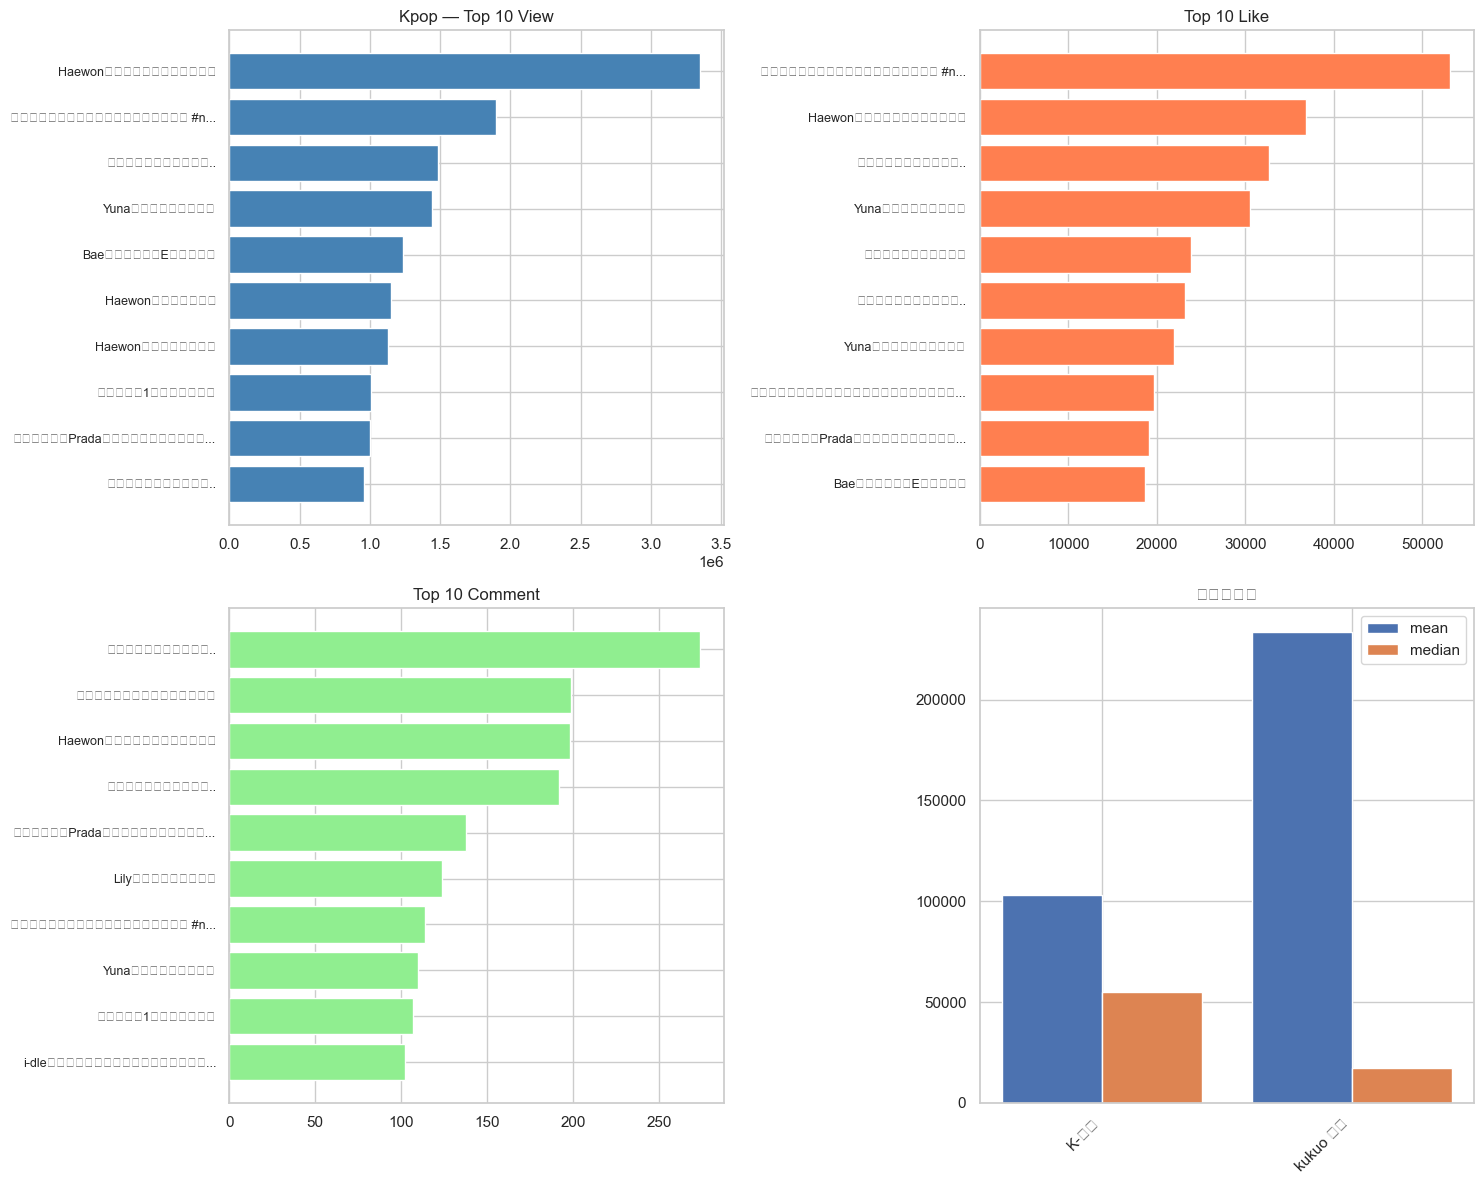

In [12]:
# Top 10 視覺化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

t10v = df_shorts.nlargest(10, 'view_count')
axes[0,0].barh(range(len(t10v)), t10v['view_count'].values, color='steelblue')
axes[0,0].set_yticks(range(len(t10v)))
axes[0,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10v['title']], fontsize=9)
axes[0,0].set_title(f'{CATEGORY_NAME} — Top 10 View'); axes[0,0].invert_yaxis()

t10l = df_shorts.nlargest(10, 'like_count')
axes[0,1].barh(range(len(t10l)), t10l['like_count'].values, color='coral')
axes[0,1].set_yticks(range(len(t10l)))
axes[0,1].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10l['title']], fontsize=9)
axes[0,1].set_title('Top 10 Like'); axes[0,1].invert_yaxis()

t10c = df_shorts.nlargest(10, 'comment_count')
axes[1,0].barh(range(len(t10c)), t10c['comment_count'].values, color='lightgreen')
axes[1,0].set_yticks(range(len(t10c)))
axes[1,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10c['title']], fontsize=9)
axes[1,0].set_title('Top 10 Comment'); axes[1,0].invert_yaxis()

ch_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean','median']).reset_index()
x = range(len(ch_summary))
axes[1,1].bar([i-0.2 for i in x], ch_summary['mean'], 0.4, label='mean')
axes[1,1].bar([i+0.2 for i in x], ch_summary['median'], 0.4, label='median')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(ch_summary['channel_title'], rotation=45, ha='right')
axes[1,1].set_title('頻道觀看數'); axes[1,1].legend()

plt.tight_layout(); plt.show()


## 9. 迴歸：兩條 OLS 線 + channel dummy

In [13]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_reg = df_shorts[['view_count','duration_sec','title_length','tag_count','channel_title']].dropna()
print(f"迴歸樣本數：{len(df_reg)}")

if len(df_reg) >= 10:
    scaler = StandardScaler()
    feats = ['duration_sec','title_length','tag_count']
    dfs = df_reg.copy()
    dfs[feats] = scaler.fit_transform(df_reg[feats])

    m1 = smf.ols('view_count ~ duration_sec + title_length + tag_count', data=dfs).fit()
    m2 = smf.ols('view_count ~ duration_sec + title_length + tag_count + C(channel_title)', data=dfs).fit()
    print("Model 1（無 channel dummy）：")
    print(m1.summary())
    print("\nModel 2（含 channel dummy）：")
    print(m2.summary())
    print(f"\nM1 R²={m1.rsquared:.4f}  Adj R²={m1.rsquared_adj:.4f}")
    print(f"M2 R²={m2.rsquared:.4f}  Adj R²={m2.rsquared_adj:.4f}")

    X = m1.model.exog
    names = m1.model.exog_names
    vif = pd.DataFrame({"Variable": names[1:],
                        "VIF": [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]})
    print("\nVIF：")
    print(vif.to_string(index=False))
else:
    print("樣本太少，跳過迴歸")


迴歸樣本數：298
Model 1（無 channel dummy）：
                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     2.887
Date:                Wed, 27 May 2026   Prob (F-statistic):             0.0359
Time:                        14:55:31   Log-Likelihood:                -4192.1
No. Observations:                 298   AIC:                             8392.
Df Residuals:                     294   BIC:                             8407.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept   

## 10. 散布圖 + 回歸線（依 channel 著色）

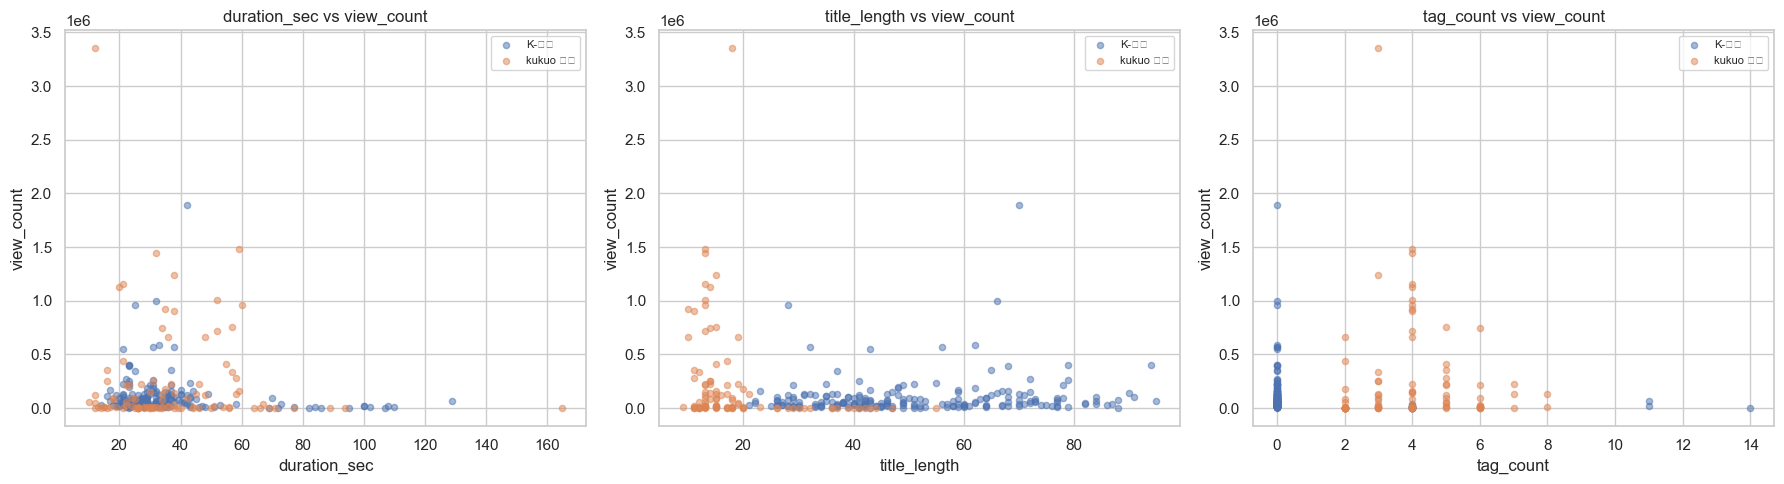

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, x_col in zip(axes, ['duration_sec','title_length','tag_count']):
    for ch, g in df_shorts.groupby('channel_title'):
        ax.scatter(g[x_col], g['view_count'], alpha=0.5, label=ch, s=20)
    ax.set_xlabel(x_col); ax.set_ylabel('view_count')
    ax.set_title(f'{x_col} vs view_count'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 11. 結論

（依分析結果手動撰寫）